In [ ]:
# Scikit-learn  -- this is an another pytohn lib  for ml
# it will help to bulid a model  or training part
# breast cancer --  whine -- flower ---all of them are trained
# they're providing this for learning purpose

# wine dataset

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# !pip install ___

In [ ]:
# loading the data set ---
wine = load_wine()
print(wine.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


In [ ]:
# creating dataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [ ]:
# understand the data --- shape, info,dec, val
print(df.shape)
print(df.info())
print(df.describe())
print(df["target"].value_counts())

(178, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64


In [ ]:
# Features and Target
X = df.drop("target",axis=1)
y = df["target"]

In [ ]:
# Train and Test Spliting
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Feature Scaliing
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Acuuracy --
print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, y_pred_lr))

# 0 -- avg | 1 - perfect | <0 - poor  = perameter of your models performence

Logistic Regression Accuracy:
1.0


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:")

print(accuracy_score(y_test, y_pred_knn))

KNN Accuracy:
0.9444444444444444


In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:")

print(accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy:
0.9444444444444444


In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")

print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
1.0


In [ ]:
print("LR  :", accuracy_score(y_test, y_pred_lr))
print("KNN :", accuracy_score(y_test, y_pred_knn))
print("DT  :", accuracy_score(y_test, y_pred_dt))
print("RF  :", accuracy_score(y_test, y_pred_rf))

LR  : 1.0
KNN : 0.9444444444444444
DT  : 0.9444444444444444
RF  : 1.0


In [ ]:
importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                         Feature  Importance
6                     flavanoids    0.202293
9                color_intensity    0.171202
12                       proline    0.139046
0                        alcohol    0.112398
11  od280/od315_of_diluted_wines    0.111564
10                           hue    0.070891
4                      magnesium    0.036841
1                     malic_acid    0.035703
3              alcalinity_of_ash    0.032425
5                  total_phenols    0.029279
8                proanthocyanins    0.023561
2                            ash    0.021282
7           nonflavanoid_phenols    0.013515


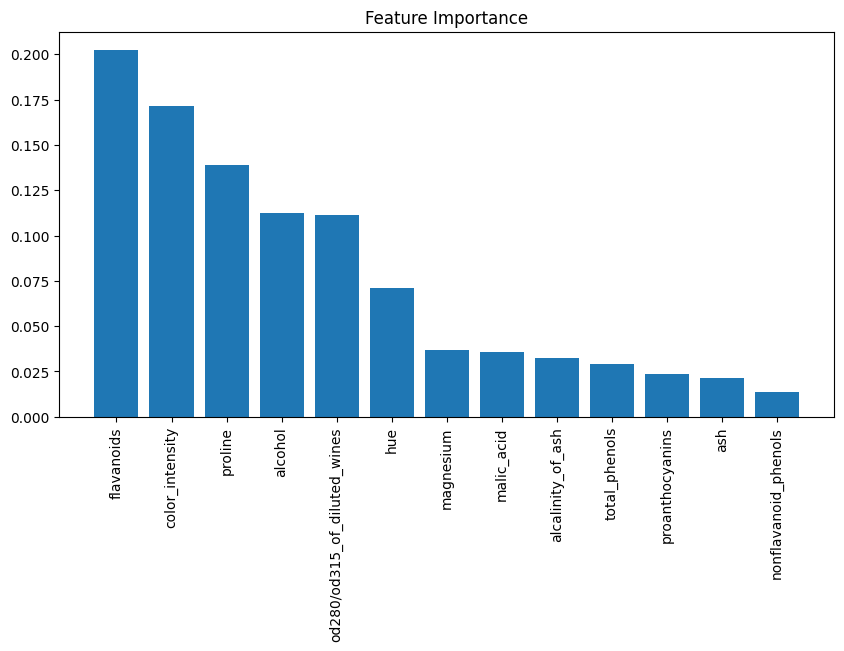

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()